<div align="center">

<br><br>

### *TP: DESAFÍO ESPECIAL*

<br>

<img src="img/logo_itba.png" width="450">

<br><br><br>

**Curso:** Ventilación Mecánica - 16.09

<br><br>

**Autor:**
Thiago Massone - 60035

<br><br>

**Fecha:** 30/06/2026

</div>

<div style="page-break-after: always;"></div>


## Consigna 4

**Objetivo:** Calcular el valor de resistencia y elastancia del sistema respiratorio por medio de una regresión lineal usando un modelo de 2 elementos en respiraciones pasivas.

### Marco teórico

El sistema respiratorio puede modelarse, en su forma más simple, como un modelo de 2 elementos (resistencia + elastancia) descripto por la ecuación de movimiento:

$$P_{aw}(t) = R \cdot F(t) + E \cdot V(t) + PEEP$$

<div align="center">
<img src="img/mod_2_elem.png" width="450">
</div>

<br>

donde:
- $R$ es la resistencia de la vía aérea
- $F(t)$ es el flujo
- $E$ es la elastancia del sistema respiratorio ($E = 1/C$, siendo $C$ la compliance)
- $V(t)$ es el volumen (integral del flujo)
- $PEEP$ es la presión positiva de fin de espiración

Este modelo es válido bajo la hipótesis de **respiración pasiva** ($P_{mus} = 0$), es decir, cuando el paciente no genera esfuerzo muscular propio y toda la energía que mueve el aire proviene del respirador (ventilación controlada).

Como se dispone de cientos de muestras por respiración (4 señales A,B,C,D), $R$, $E$ y $PEEP$ no se despejan algebraicamente sino que se estiman ajustando por **cuadrados mínimos** (regresión lineal) los valores medidos de $F$, $V$ y $P_{aw}$.

### Desarrollo

1. Exploración de las señales disponibles y selección de la más adecuada
2. Selección de uno o unos tramos de respiración pasiva, justificado con la curva de presión esofágica (Pes)
3. Cálculo del volumen por integración del flujo
4. Ajuste del modelo por regresión lineal (cuadrados mínimos) en cada tramo seleccionado
5. Comparación de los resultados obtenidos y promedio de los parámetros
6. Validación del modelo promediado
7. Conclusión

In [3]:
%pip install pandas numpy matplotlib plotly nbformat ipython


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)

## 1. Exploración de las señales disponibles y selección de la más adecuada

Se dispone de 4 archivos de registro (`Mini_TP_Signals_A/B/C/D.txt`) provenientes de un sistema FluxMed a 256 Hz, con las columnas: Time, Flow, Volume, Paw, Pes, Ptpulm, Pga, Ptdiaf, CO2.

Antes de elegir con qué señal trabajar, se exploraron los 4 archivos para identificar cuál tiene ciclos respiratorios limpios y con minimo o nulo esfuerzo del paciente (sin Pmus con Pesof estable), condición necesaria para poder ajustar el modelo de 2 elementos.

In [5]:
cols = ['Time','Flow','Volume','Paw','Pes','Ptpulm','Pga','Ptdiaf','CO2']
fs = 256  # Hz
dt = 1/fs

dfs = {}
for f in ['A','B','C','D']:
    dfs[f] = pd.read_csv(f'signals/Mini_TP_Signals_{f}.txt', sep='\t', skiprows=6, names=cols,
                          usecols=range(9), encoding='latin-1')
    dur = dfs[f].Time.iloc[-1] - dfs[f].Time.iloc[0]
    print(f"Archivo {f}: {len(dfs[f])} muestras, duración {dur:.0f} s")

Archivo A: 209920 muestras, duración 820 s
Archivo B: 140800 muestras, duración 550 s
Archivo C: 30208 muestras, duración 118 s
Archivo D: 431596 muestras, duración 1686 s


### Exploración interactiva de las señales completas

Antes de aislar ciclos puntuales, se generó una visualización interactiva (zoom, pan y desplazamiento) de las 4 señales completas, para poder recorrerlas libremente y localizar tramos de interés (tanto para descartar señales como para identificar más adelante tramos de respiración pasiva).

In [7]:
import plotly.graph_objects as go

for f in ['A','B','C','D']:
    d = dfs[f].iloc[::16]  # downsample a ~16 Hz solo para visualización
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=d.Time, y=d.Flow, name='Flow (L/min)', line=dict(width=1)))
    fig.add_trace(go.Scatter(x=d.Time, y=d.Paw, name='Paw (cmH2O)', line=dict(width=1)))
    fig.update_layout(
        title=f'Señal {f} — exploración interactiva',
        xaxis=dict(title='Tiempo (s)', rangeslider=dict(visible=True, thickness=0.12)),
        yaxis=dict(title='Flow / Paw'),
        height=380, width=950,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
        margin=dict(t=80, b=40)
    )
    fig.show()

**Nota sobre el origen de los archivos:** los tiempos de inicio y fin de cada archivo son consecutivos entre sí (A: 0–820s, B: 820–1370s, C: 1377–1495s, D: 1512–3198s), por lo que es altamente probable que los 4 archivos correspondan a un único registro continuo de aproximadamente 53 minutos, exportado en tramos consecutivos, y no a 4 pacientes o mediciones independientes. Bajo esta hipótesis, el objetivo de la exploración inicial pasa a ser identificar, dentro de este único registro, el tramo más adecuado para el análisis.

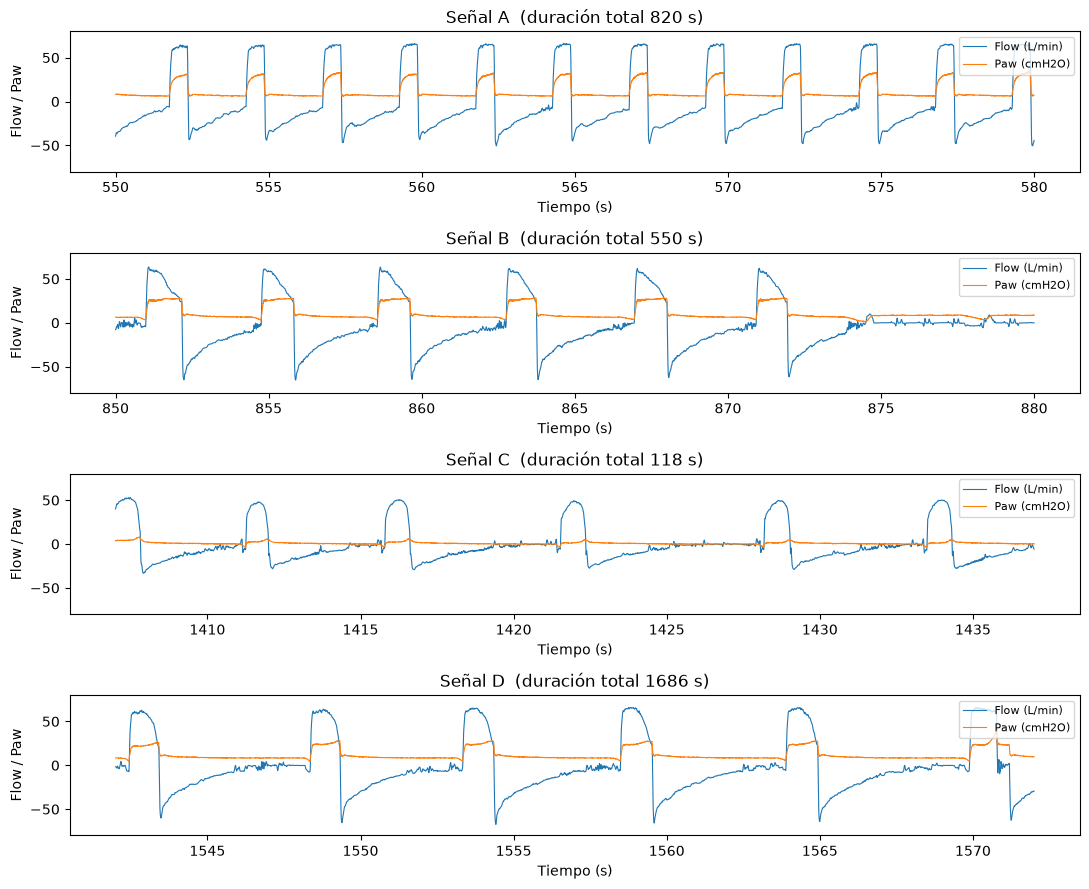

In [8]:
# Panorama general: los 4 archivos
ventanas = {'A': 550, 'B': 850, 'C': 1407, 'D': 1542}  # tiempo de inicio de cada ventana (s)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=False)
for ax, f in zip(axes, ['A','B','C','D']):
    d = dfs[f]
    t0 = ventanas[f]
    sub = d[(d.Time >= t0) & (d.Time < t0+30)]
    ax.plot(sub.Time, sub.Flow, label='Flow (L/min)', linewidth=0.8)
    ax.plot(sub.Time, sub.Paw, label='Paw (cmH2O)', linewidth=0.8)
    dur = d.Time.iloc[-1] - d.Time.iloc[0]
    ax.set_title(f'Señal {f}  (duración total {dur:.0f} s)')
    ax.set_ylim(-80, 80)
    ax.set_ylabel('Flow / Paw')
    ax.set_xlabel('Tiempo (s)')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('fig0_comparacion_archivos.png', dpi=150)
plt.show()

### Identificación del modo de ventilación

Se aisla un ciclo respiratorio individual de cada archivo para comparar la forma de las curvas de Flow y Paw. Para todas las señales se verificó además, sobre el registro completo, que el ciclo elegido es representativo del comportamiento general (no un caso atípico).

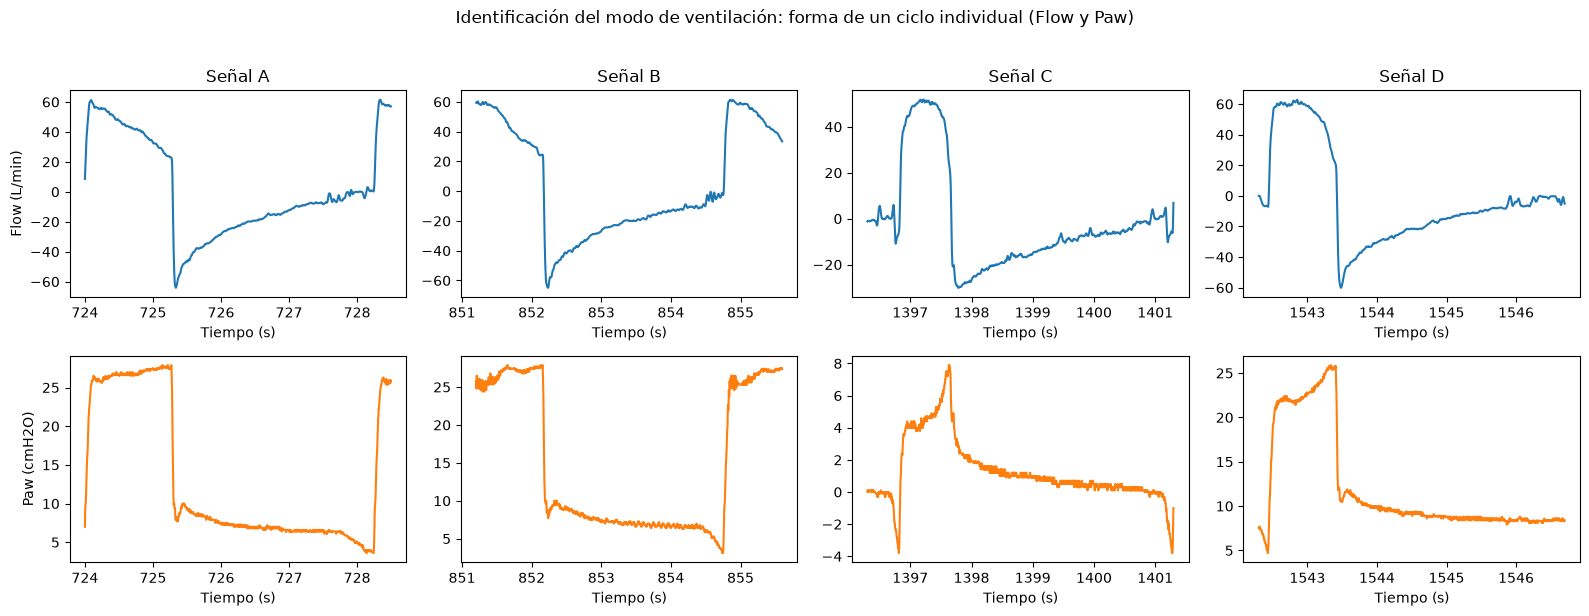

In [9]:
ciclos = {
    'A': (724.0, 728.5),
    'B': (851.2, 855.6),
    'C': (1396.3, 1401.3),
    'D': (1542.3, 1546.7),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=False)
for col, f in enumerate(['A','B','C','D']):
    d = dfs[f]
    t0, t1 = ciclos[f]
    sub = d[(d.Time>=t0)&(d.Time<t1)]

    axes[0, col].plot(sub.Time, sub.Flow, color='tab:blue')
    axes[0, col].set_title(f'Señal {f}')
    axes[0, col].set_xlabel('Tiempo (s)')
    if col == 0:
        axes[0, col].set_ylabel('Flow (L/min)')

    axes[1, col].plot(sub.Time, sub.Paw, color='tab:orange')
    axes[1, col].set_xlabel('Tiempo (s)')
    if col == 0:
        axes[1, col].set_ylabel('Paw (cmH2O)')

fig.suptitle('Identificación del modo de ventilación: forma de un ciclo individual (Flow y Paw)', y=1.02)
plt.tight_layout()
plt.savefig('fig0c_tipo_control.png', dpi=150, bbox_inches='tight')
plt.show()

En las **señales A y B**, Paw alcanza una **meseta plana y sostenida** durante gran parte de la inspiración, sin variar prácticamente nada (~26-28 cmH2O). Esto nos indica **ventilación controlada por presión (PCV)**: el respirador mantiene la presión objetivo constante mientras dura la inspiración.

En las **señales C y D**, en cambio, Paw **no presenta meseta**: sube hasta un pico y comienza a decaer de inmediato (de forma más suave en D, más abrupta en C, asociado probablemente a diferencias en la mecánica respiratoria del paciente). Este comportamiento es consistente con **ventilación controlada por volumen (VCV)**, donde el respirador impone un flujo/volumen fijo y la presión resultante depende de la respuesta mecánica del sistema respiratorio.

**Selección de la señal de trabajo:**

- **Archivo A:** 

In [10]:
total_dur = dfs['A'].Time.iloc[-1] - dfs['A'].Time.iloc[0]
muerto = dfs['A'][dfs['A'].Time < 504]

print(f"Duración total de la señal A: {total_dur:.0f} s")
print(f"Tramo sin flujo real (t<504s): {504:.0f} s ({504/total_dur*100:.0f}% del archivo)")
print(f"Desviación estándar de Flow en ese tramo: {muerto.Flow.std():.2f} L/min")

Duración total de la señal A: 820 s
Tramo sin flujo real (t<504s): 504 s (61% del archivo)
Desviación estándar de Flow en ese tramo: 0.35 L/min


#### Descarte de la señal A

La señal A no presenta flujo real durante el 61% de su duración (de t=0 a t≈504s, con una desviación estándar de Flow de apenas 0.35 L/min, propia de ruido de instrumentación y no de ciclado respiratorio). Recién a partir de t≈504s aparece señal con amplitud comparable a las demás (std ≈ 40 L/min) por lo que se opta por una señal con mayor información para un mejor resultado en la regresión lineal.

**Se descarta la señal A como candidata para el análisis de la consigna 4.**

- **Archivo B:** 

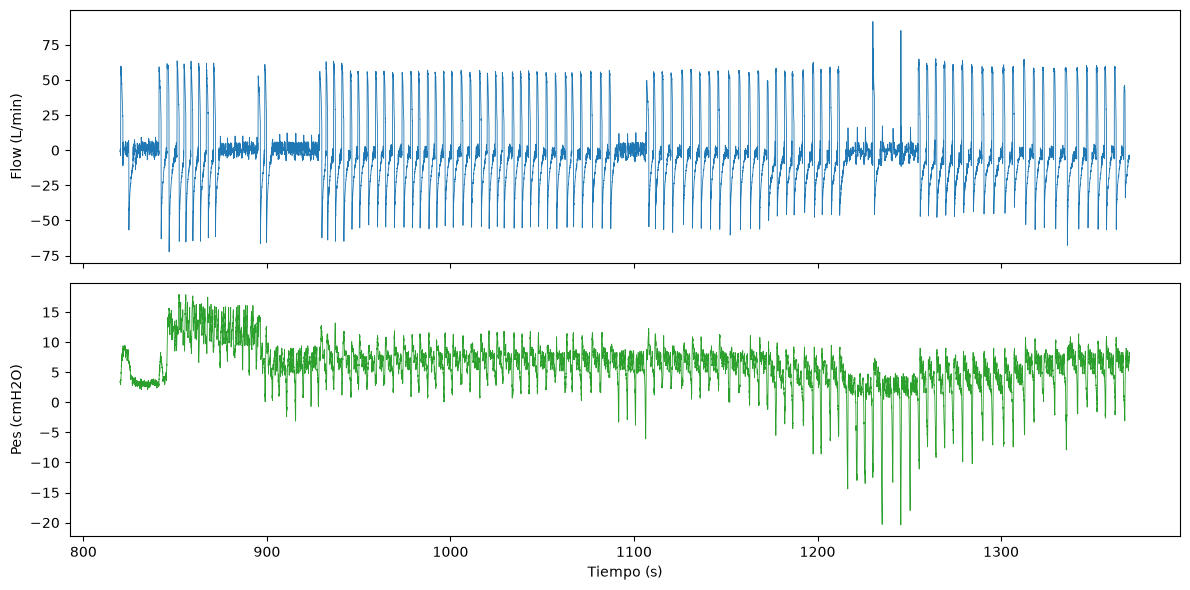

Duración de la señal B: 550 s
Pes: media=6.0 cmH2O, std=3.9 cmH2O, min=-20.4, max=17.9


In [11]:
dur_B = dfs['B'].Time.iloc[-1] - dfs['B'].Time.iloc[0]

fig, axes = plt.subplots(2,1, figsize=(12,6), sharex=True)
axes[0].plot(dfs['B'].Time, dfs['B'].Flow, linewidth=0.6)
axes[0].set_ylabel('Flow (L/min)')
axes[1].plot(dfs['B'].Time, dfs['B'].Pes, linewidth=0.6, color='tab:green')
axes[1].set_ylabel('Pes (cmH2O)')
axes[1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.savefig('fig_descarte_B.png', dpi=150)
plt.show()

print(f"Duración de la señal B: {dur_B:.0f} s")
print(f"Pes: media={dfs['B'].Pes.mean():.1f} cmH2O, std={dfs['B'].Pes.std():.1f} cmH2O, "
      f"min={dfs['B'].Pes.min():.1f}, max={dfs['B'].Pes.max():.1f}")

#### Descarte de la señal B

Si bien la señal B presenta ciclos regulares en modo PCV, la curva de Pes muestra variaciones considerables a lo largo del registro (std = 3.87 cmH2O, llegando a picos de hasta -20 cmH2O en algunos tramos), lo cual indica presencia de esfuerzo inspiratorio activo del paciente en buena parte del archivo. Además, se observan breves intervalos (t≈840s y t≈895s) donde el ciclado prácticamente desaparece.

Dado que la consigna requiere un tramo de respiración **pasiva** (Pmus≈0) **se descarta la señal B**.


- **Archivo C:** 

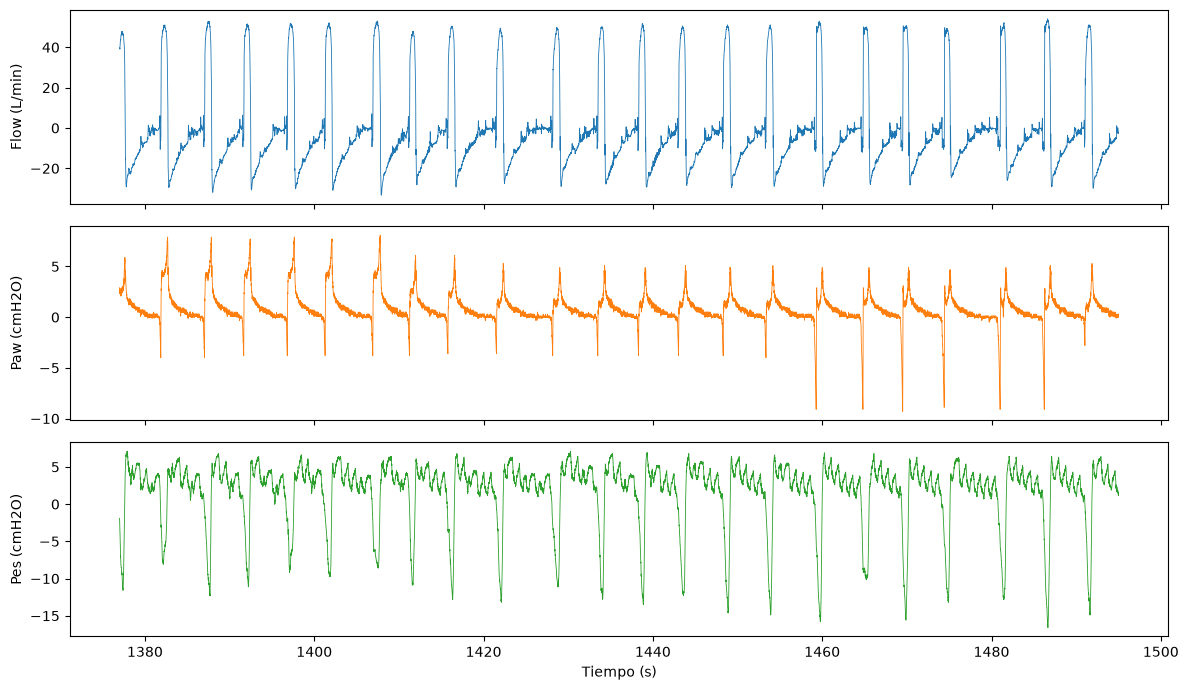

Duración de la señal C: 118 s
Pes: media=1.7 cmH2O, std=4.5 cmH2O, min=-16.6, max=7.1
Paw: media=0.9 cmH2O, min=-9.3, max=8.1


In [12]:
dur_C = dfs['C'].Time.iloc[-1] - dfs['C'].Time.iloc[0]

fig, axes = plt.subplots(3,1, figsize=(12,7), sharex=True)
axes[0].plot(dfs['C'].Time, dfs['C'].Flow, linewidth=0.6)
axes[0].set_ylabel('Flow (L/min)')
axes[1].plot(dfs['C'].Time, dfs['C'].Paw, linewidth=0.6, color='tab:orange')
axes[1].set_ylabel('Paw (cmH2O)')
axes[2].plot(dfs['C'].Time, dfs['C'].Pes, linewidth=0.6, color='tab:green')
axes[2].set_ylabel('Pes (cmH2O)')
axes[2].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.savefig('fig_descarte_C.png', dpi=150)
plt.show()

print(f"Duración de la señal C: {dur_C:.0f} s")
print(f"Pes: media={dfs['C'].Pes.mean():.1f} cmH2O, std={dfs['C'].Pes.std():.1f} cmH2O, "
      f"min={dfs['C'].Pes.min():.1f}, max={dfs['C'].Pes.max():.1f}")
print(f"Paw: media={dfs['C'].Paw.mean():.1f} cmH2O, min={dfs['C'].Paw.min():.1f}, max={dfs['C'].Paw.max():.1f}")

#### Descarte de la señal C

En la señal C, Pes presenta una caída brusca y rítmica en cada ciclo respiratorio (llegando a valores de entre -8 y -16 cmH2O de forma sistemática, no aislada), lo cual es evidencia clara de esfuerzo inspiratorio activo del paciente en prácticamente todas las respiraciones del registro. Paw acompaña este patrón, nunca superando los 8 cmH2O y presentando también incursiones a presión negativa en cada ciclo. Además, la duración total de la señal (118 s) es considerablemente menor a la de las demás.

Dado que la consigna requiere un tramo de respiración **pasiva** (Pmus≈0), **se descarta la señal C**.

- **Archivo D:** 

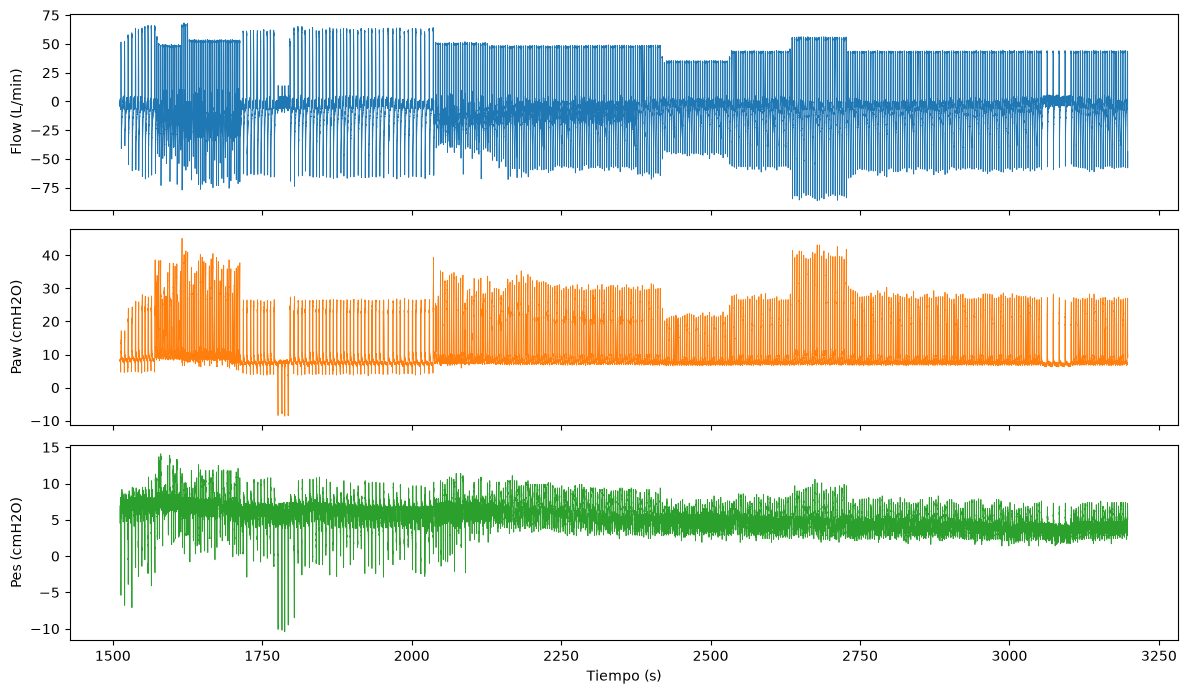

Duración de la señal D: 1686 s
Pes: media=5.4 cmH2O, std=2.0 cmH2O, min=-10.4, max=14.1


In [13]:
dur_D = dfs['D'].Time.iloc[-1] - dfs['D'].Time.iloc[0]

fig, axes = plt.subplots(3,1, figsize=(12,7), sharex=True)
axes[0].plot(dfs['D'].Time, dfs['D'].Flow, linewidth=0.6)
axes[0].set_ylabel('Flow (L/min)')
axes[1].plot(dfs['D'].Time, dfs['D'].Paw, linewidth=0.6, color='tab:orange')
axes[1].set_ylabel('Paw (cmH2O)')
axes[2].plot(dfs['D'].Time, dfs['D'].Pes, linewidth=0.6, color='tab:green')
axes[2].set_ylabel('Pes (cmH2O)')
axes[2].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.savefig('fig_seleccion_D.png', dpi=150)
plt.show()

print(f"Duración de la señal D: {dur_D:.0f} s")
print(f"Pes: media={dfs['D'].Pes.mean():.1f} cmH2O, std={dfs['D'].Pes.std():.1f} cmH2O, "
      f"min={dfs['D'].Pes.min():.1f}, max={dfs['D'].Pes.max():.1f}")

#### Análisis de la señal D

La señal D presenta la menor variabilidad de Pes de las tres señales con ciclado real (std=2.02 cmH2O, frente a 3.87 en B y 4.47 en C), sin los picos negativos profundos y rítmicos observados en C. Es además, con 1686 s, la de mayor duración disponible. No obstante, se observan zonas con mayor variabilidad dentro del propio registro (por ejemplo, entre t≈1600-1700s).




### Comparación de señales B, C y D (la señal A ya fue descartada)

Se compara la variabilidad de la presión esofágica (Pes) entre las tres señales con ciclado respiratorio real, ya que es el indicador clave para evaluar qué tan cerca está cada una de una respiración pasiva (a menor variabilidad de Pes, menor esfuerzo activo del paciente).

In [14]:
rows = []
for f in ['B','C','D']:
    d = dfs[f]
    dur = d.Time.iloc[-1] - d.Time.iloc[0]
    rows.append({
        'Señal': f,
        'Duración (s)': round(dur),
        'Pes media (cmH2O)': round(d.Pes.mean(),2),
        'Pes std (cmH2O)': round(d.Pes.std(),2),
        'Pes min (cmH2O)': round(d.Pes.min(),2),
        'Pes max (cmH2O)': round(d.Pes.max(),2),
    })

tabla_comparativa = pd.DataFrame(rows)
tabla_comparativa

,Señal,Duración (s),Pes media (cmH2O),Pes std (cmH2O),Pes min (cmH2O),Pes max (cmH2O)
0,B,550,5.95,3.87,-20.4,17.9
1,C,118,1.72,4.47,-16.6,7.1
2,D,1686,5.39,2.02,-10.4,14.1


**Se selecciona la señal D** para continuar el análisis, no solo por presentar la menor variabilidad de Pes (mayor cercanía a respiración pasiva), sino también por su mayor duración (1686 s, muestreada a 256 Hz, equivalente a más de 430.000 muestras). Esto resulta especialmente conveniente para la consigna, ya que ofrece más tramos candidatos entre los cuales elegir, y una mayor cantidad de muestras por ciclo aporta mayor robustez estadística a la regresión lineal utilizada para estimar R y C.

In [15]:
df = dfs['D']

In [16]:
flow = df.Flow.values
flow_pos = flow[flow > 0]
picos = flow_pos[flow_pos > np.percentile(flow_pos, 95)]
threshold = 0.5 * picos.mean()

cruces = np.where((flow[:-1] < threshold) & (flow[1:] >= threshold))[0]
n_ciclos = len(cruces)
dur_total = df.Time.iloc[-1] - df.Time.iloc[0]

fr = n_ciclos / (dur_total/60)  # resp/min
periodo = dur_total / n_ciclos  # s/ciclo

print(f"Cantidad de ciclos detectados en D: {n_ciclos}")
print(f"Frecuencia respiratoria promedio: {fr:.1f} resp/min")
print(f"Período promedio por ciclo: {periodo:.2f} s")

Cantidad de ciclos detectados en D: 409
Frecuencia respiratoria promedio: 14.6 resp/min
Período promedio por ciclo: 4.12 s


**Frecuencia respiratoria de la señal D:** se detectaron 409 ciclos respiratorios a lo largo del registro completo, lo que equivale a una frecuencia respiratoria promedio de 14.6 resp/min (período promedio de 4.12 s por ciclo), dentro del rango fisiológico normal para un adulto (12-20 resp/min). Esto confirma que una ventana de 4 segundos es adecuada para capturar un ciclo respiratorio completo, criterio utilizado tanto en la búsqueda de tramos pasivos como en el cálculo de volumen.

**Nota sobre la columna Volume:** el volumen provisto por el equipo es un acumulador crudo que no se resetea por ciclo (satura en ±32768), por lo que **no se utiliza directamente**; el volumen se recalcula más adelante integrando el flujo.

## 2. Selección del tramo de respiración pasiva

Para que el modelo de 2 elementos sea válido, el paciente no debe estar generando esfuerzo muscular propio (Pmus = 0), es decir, debe tratarse de **ventilación controlada/pasiva**.

Pmus no se puede medir de forma directa, pero existe una forma indirecta de estimarla a partir de la **presión esofágica (Pes)**: dado que el esófago está próximo al espacio pleural, Pes es utilizada como subrogado de la presión pleural. Esta, a su vez, es la suma del retroceso elástico de la caja torácica más la presión generada por los músculos respiratorios (principalmente el diafragma durante la inspiración). Por lo tanto, cuando el paciente activa el diafragma para inspirar, la presión pleural cae, y esa caída se manifiesta como una disminución brusca en Pes al inicio de la inspiración. En una respiración pasiva, en cambio, sin actividad diafragmática, Pes debe variar de forma suave y monótona en paralelo con Paw, sin esas caídas bruscas.

Para identificar candidatos a respiración pasiva dentro de D, se calculó el desvío estándar de Pes en ventanas móviles de 4 segundos a lo largo de todo el registro, descartando las ventanas sin ciclado real (Paw prácticamente constante).

In [17]:
# Búsqueda de candidatos a respiración pasiva: ventanas de 4s con menor variabilidad de Pes
win = fs * 4  # ventana de 4 segundos
pes = df.Pes.values
paw = df.Paw.values
n = len(df)

candidatos = []
for start in range(0, n - win, win // 2):
    seg_pes = pes[start:start+win]
    seg_paw = paw[start:start+win]
    if seg_paw.std() < 2:  # descartar ventanas sin ciclado real (Paw constante)
        continue
    candidatos.append((df.Time.iloc[start], seg_pes.std(), seg_pes.max() - seg_pes.min()))

candidatos.sort(key=lambda x: x[1])  # ordenar por menor desvío estándar de Pes

print("Top 15 ventanas con menor desvío estándar de Pes (candidatos a respiración pasiva):")
print(f"{'t inicio (s)':>15} {'Pes std (cmH2O)':>18} {'Pes rango (cmH2O)':>20}")
for t0, std, rng in candidatos[:15]:
    print(f"{t0:>15.1f} {std:>18.2f} {rng:>20.2f}")

Top 15 ventanas con menor desvío estándar de Pes (candidatos a respiración pasiva):
   t inicio (s)    Pes std (cmH2O)    Pes rango (cmH2O)
         2092.0               0.85                 4.20
         2122.0               0.92                 4.00
         2136.0               0.95                 4.40
         2090.0               0.97                 6.00
         2120.0               0.97                 3.80
         2134.0               0.99                 4.90
         3092.0               1.00                 5.00
         2132.0               1.00                 5.10
         2444.0               1.02                 4.50
         3172.0               1.02                 5.00
         3022.0               1.03                 5.40
         2430.0               1.03                 3.70
         2098.0               1.03                 5.20
         3174.0               1.04                 5.00
         2486.0               1.05                 4.20


In [18]:
candidatos = []
for start in range(0, n - win, win // 2):
    seg_pes = pes[start:start+win]
    seg_paw = paw[start:start+win]
    if seg_paw.std() < 2:
        continue
    candidatos.append((df.Time.iloc[start], seg_pes.std(), seg_pes.max() - seg_pes.min()))

candidatos.sort(key=lambda x: x[1])

seleccionados = []
usados = []
for t0, std, rng in candidatos:
    if any(abs(t0 - t_prev) < 60 for t_prev in usados):
        continue
    seleccionados.append((t0, std, rng))
    usados.append(t0)
    if len(seleccionados) == 8:
        break

print("8 candidatos con diversidad temporal (≥60s entre sí):")
print(f"{'t inicio (s)':>15} {'Pes std (cmH2O)':>18} {'Pes rango (cmH2O)':>20}")
for t0, std, rng in seleccionados:
    print(f"{t0:>15.1f} {std:>18.2f} {rng:>20.2f}")

8 candidatos con diversidad temporal (≥60s entre sí):
   t inicio (s)    Pes std (cmH2O)    Pes rango (cmH2O)
         2092.0               0.85                 4.20
         3092.0               1.00                 5.00
         2444.0               1.02                 4.50
         3172.0               1.02                 5.00
         3022.0               1.03                 5.40
         2812.0               1.06                 4.80
         2522.0               1.09                 4.50
         1584.0               1.09                 4.70


Aplicando diversidad temporal (priorizando candidatos separados por al menos 60s entre sí) sobre esta lista, se obtienen los primeros 4 candidatos. Como cada ventana corresponde a un único ciclo (no varios), se grafican con algo de contexto adicional (más allá de los 4s exactos de la ventana) antes de aceptarlos, para poder distinguir un ciclo respiratorio real de un tramo que, aunque cumple el criterio numérico de baja variabilidad de Pes, en realidad corresponde a una respiración aislada rodeada de tramos sin flujo.

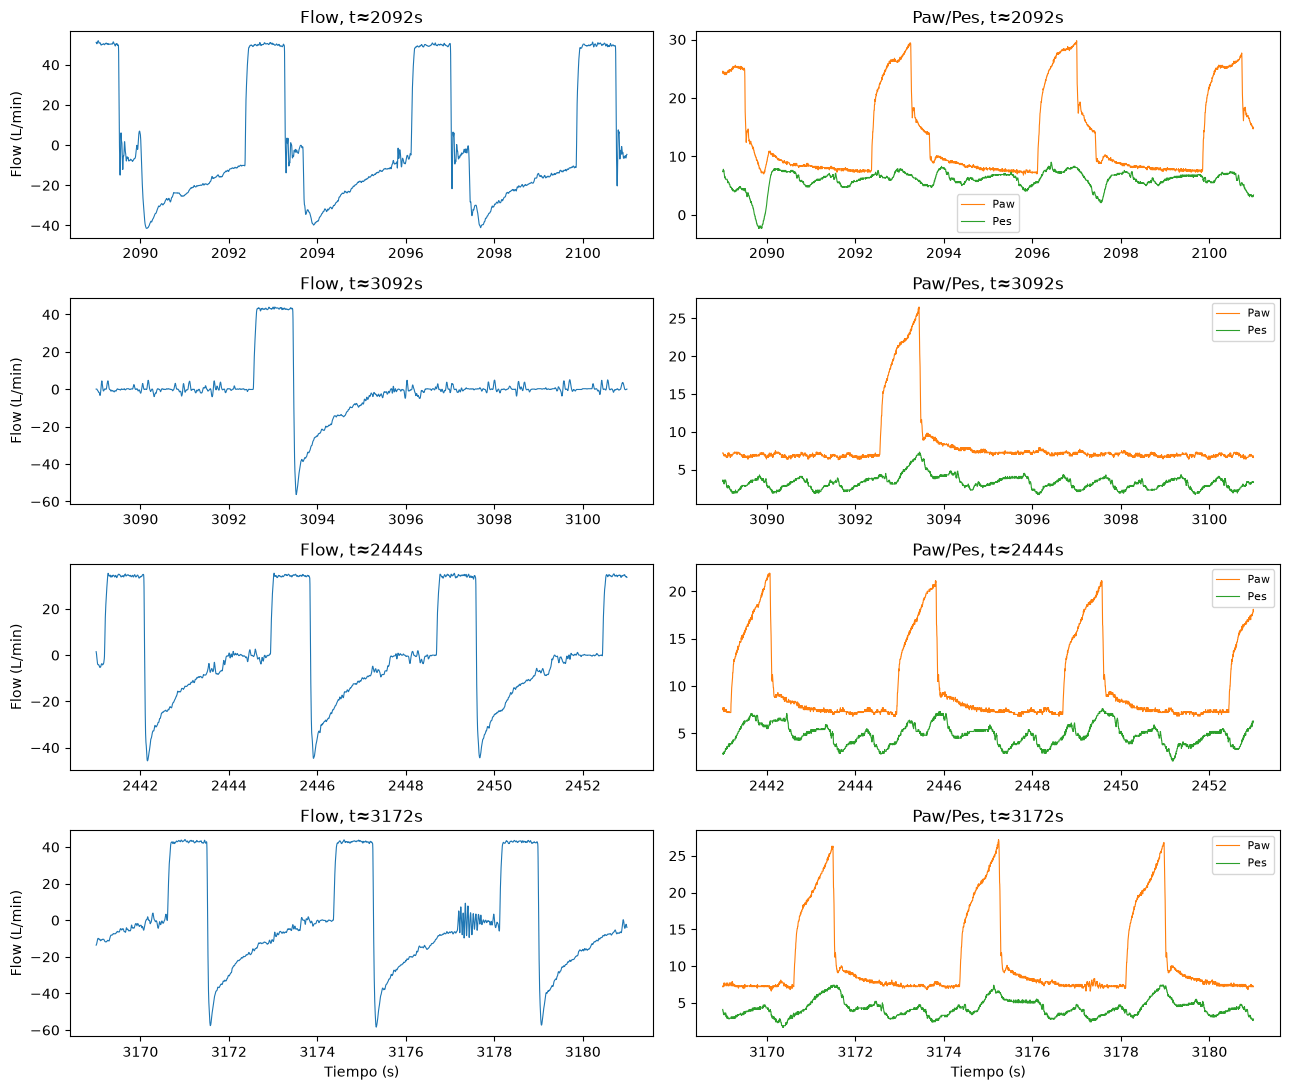

In [19]:
# Diversidad temporal sobre el primer criterio (sin el filtro de cantidad de ciclos)
seleccionados_v1 = []
usados = []
for t0, std, rng in candidatos:
    if any(abs(t0 - t_prev) < 60 for t_prev in usados):
        continue
    seleccionados_v1.append(t0)
    usados.append(t0)
    if len(seleccionados_v1) == 4:
        break

fig, axes = plt.subplots(len(seleccionados_v1), 2, figsize=(13, 11))
for i, t0 in enumerate(seleccionados_v1):
    sub = df[(df.Time >= t0-3) & (df.Time < t0+9)]
    axes[i,0].plot(sub.Time, sub.Flow, linewidth=0.8)
    axes[i,0].set_title(f'Flow, t≈{t0:.0f}s')
    axes[i,0].set_ylabel('Flow (L/min)')
    axes[i,1].plot(sub.Time, sub.Paw, linewidth=0.8, color='tab:orange', label='Paw')
    axes[i,1].plot(sub.Time, sub.Pes, linewidth=0.8, color='tab:green', label='Pes')
    axes[i,1].set_title(f'Paw/Pes, t≈{t0:.0f}s')
    axes[i,1].legend(fontsize=8)
axes[-1,0].set_xlabel('Tiempo (s)')
axes[-1,1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.savefig('fig_candidatos_v1.png', dpi=150)
plt.show()

Al aplicar diversidad temporal (priorizando candidatos separados por al menos 60s entre sí) sobre esta lista, uno de los 4 seleccionados correspondió a t=3092s. Sin embargo, al graficar este tramo se observó que la ventana contenía un único ciclo respiratorio aislado, rodeado de un tramo prácticamente sin flujo y no varios ciclos consecutivos como en los demás candidatos. El criterio de "menor desvío estándar de Pes" por sí solo no distingue este caso, porque la baja variabilidad de Pes en ese tramo se debe a la ausencia de ciclado, no a que el paciente esté pasivo durante varias respiraciones.

Analizamos el siguiente mejor tramo a modo de encontrar alguno con mas de una respiración.

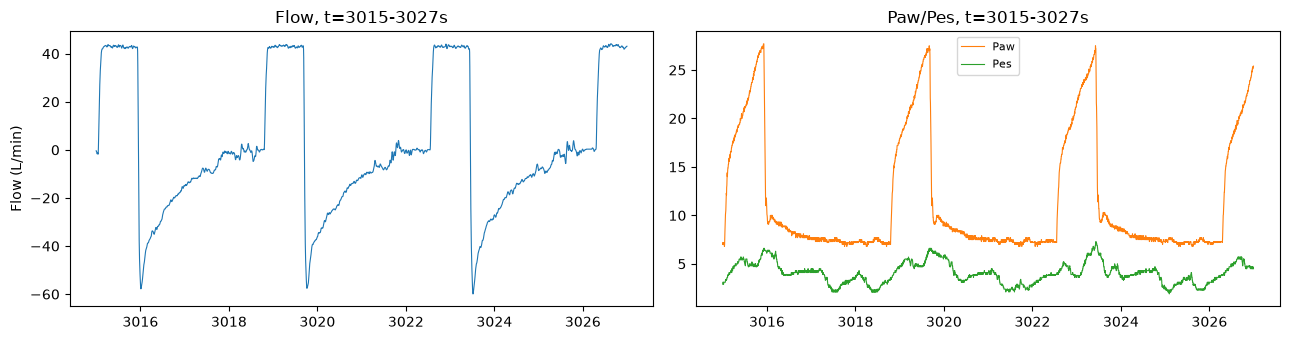

In [20]:
t0 = 3015
sub = df[(df.Time >= t0) & (df.Time < t0+12)]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(sub.Time, sub.Flow, linewidth=0.8)
axes[0].set_title(f'Flow, t={t0}-{t0+12}s')
axes[0].set_ylabel('Flow (L/min)')
axes[1].plot(sub.Time, sub.Paw, linewidth=0.8, color='tab:orange', label='Paw')
axes[1].plot(sub.Time, sub.Pes, linewidth=0.8, color='tab:green', label='Pes')
axes[1].set_title(f'Paw/Pes, t={t0}-{t0+12}s')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig_candidato_3022.png', dpi=150)
plt.show()

Con esto, los 4 ciclos finales seleccionados para la regresión son:

| Ciclo | Rango temporal |
|---|---|
| 1 | t = 2092.0 – 2096.0 s |
| 2 | t = 2444.0 – 2448.0 s |
| 3 | t = 3172.0 – 3176.0 s |
| 4 | t = 3022.0 – 3026.0 s |

Sobre cada uno de estos ciclos (1 ciclo por intervalo) se realizará una regresión lineal independiente, comparando los valores de R y C obtenidos entre sí para evaluar la consistencia de la estimación.

## 3. Cálculo del volumen

El volumen V(t) se obtiene integrando numéricamente el flujo (suma acumulada * dt), y se resetea a 0 al inicio del tramo analizado (volumen relativo del segmento).

**Nota de unidades:** el flujo está en L/min en el archivo original. Para integrarlo en el tiempo (que está en segundos) y obtener un volumen en litros, se debe convertir el flujo a L/s dividiendo por 60.

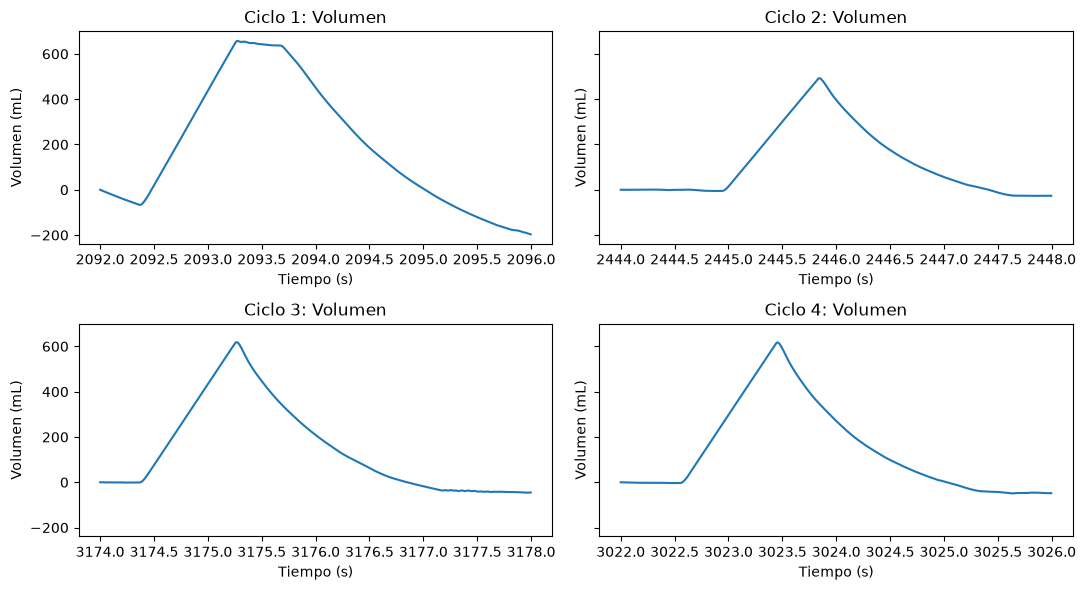

In [21]:
def calcular_volumen(t0, t1, df, fs):
    """Recorta un tramo del DataFrame y agrega la columna de volumen integrando el flujo."""
    ciclo = df[(df.Time >= t0) & (df.Time < t1)].reset_index(drop=True)
    flow_Ls = ciclo.Flow.values / 60.0  # conversión L/min -> L/s
    dt = 1 / fs
    volumen = np.cumsum(flow_Ls) * dt
    volumen = volumen - volumen[0]  # volumen relativo, arranca en 0
    ciclo = ciclo.copy()
    ciclo['Vol_L'] = volumen
    return ciclo

# Rangos de los 4 ciclos seleccionados
rangos = {
    1: (2092, 2096),
    2: (2444, 2448),
    3: (3174, 3178),
    4: (3022, 3026),
}

ciclos = {n: calcular_volumen(t0, t1, df, fs) for n, (t0, t1) in rangos.items()}

# Verificación rápida: graficar el volumen de cada ciclo
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharey=True)
for ax, n in zip(axes.flat, ciclos):
    c = ciclos[n]
    ax.plot(c.Time, c.Vol_L * 1000)  # mostrar en mL
    ax.set_title(f'Ciclo {n}: Volumen')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Volumen (mL)')
plt.tight_layout()
plt.savefig('fig_volumenes_4ciclos.png', dpi=150)
plt.show()

Se observa que la ventana de menor desvío estándar de Pes no necesariamente coincide con el inicio de una inspiración: el criterio de búsqueda solo evalúa la variabilidad de Pes dentro de una ventana de tiempo fija, sin tener en cuenta en qué punto del ciclo respiratorio arranca esa ventana. Esto ocurrió con el Ciclo 3 (t=3172s), cuya ventana comenzaba a mitad de una espiración. Para esta entrega, se ajustó manualmente el rango de este ciclo (a t=3174–3178s) para que coincida con el inicio real de la inspiración.

Como mejora futura, el algoritmo de detección podría incorporar la ubicación exacta del inicio de cada ciclo (por ejemplo, mediante los cruces ascendentes de flujo ya calculados) para alinear automáticamente cada ventana candidata con el comienzo de una inspiración, en lugar de ajustar manualmente los casos desalineados.
| Ciclo | Rango temporal |
|---|---|
| 1 | t = 2092 – 2096 s |
| 2 | t = 2444 – 2448 s |
| 3 | t = 3174 – 3178 s |
| 4 | t = 3022 – 3026 s |

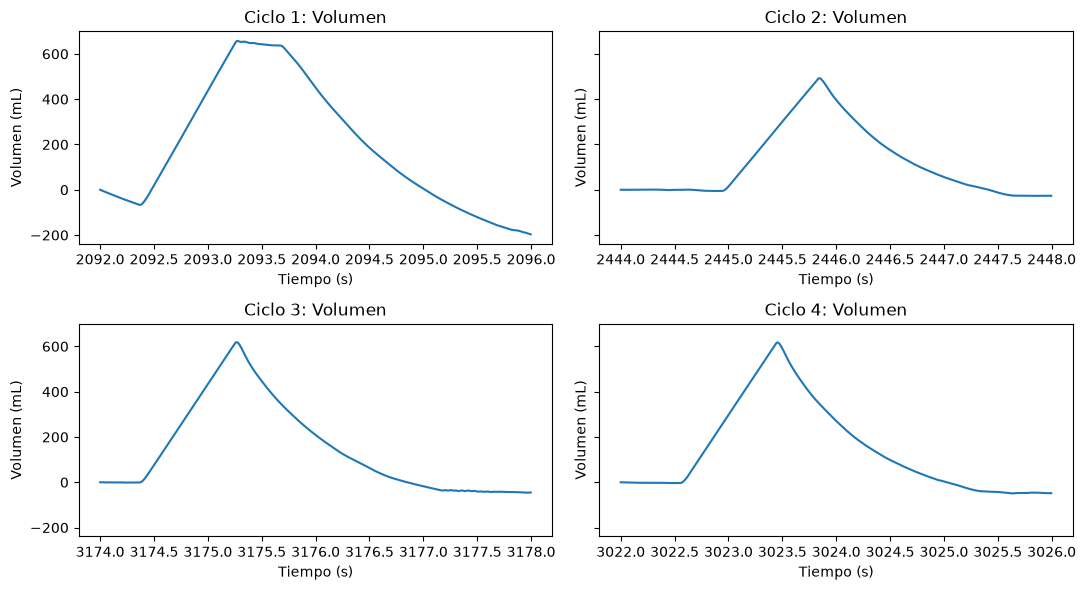

In [22]:
def calcular_volumen(t0, t1, df, fs):
    """Recorta un tramo del DataFrame y agrega la columna de volumen integrando el flujo."""
    ciclo = df[(df.Time >= t0) & (df.Time < t1)].reset_index(drop=True)
    flow_Ls = ciclo.Flow.values / 60.0  # conversión L/min -> L/s
    dt = 1 / fs
    volumen = np.cumsum(flow_Ls) * dt
    volumen = volumen - volumen[0]  # volumen relativo, arranca en 0
    ciclo = ciclo.copy()
    ciclo['Vol_L'] = volumen
    return ciclo

# Rangos de los 4 ciclos seleccionados
rangos = {
    1: (2092, 2096),
    2: (2444, 2448),
    3: (3174, 3178),
    4: (3022, 3026),
}

ciclos = {n: calcular_volumen(t0, t1, df, fs) for n, (t0, t1) in rangos.items()}

# Verificación rápida: graficar el volumen de cada ciclo
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharey=True)
for ax, n in zip(axes.flat, ciclos):
    c = ciclos[n]
    ax.plot(c.Time, c.Vol_L * 1000)  # mostrar en mL
    ax.set_title(f'Ciclo {n}: Volumen')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Volumen (mL)')
plt.tight_layout()
plt.savefig('fig_volumenes_4ciclos.png', dpi=150)
plt.show()

Los 4 ciclos presentan volúmenes de inspiración coherentes entre sí (entre ~480 y 650 mL), dentro de rangos fisiológicos razonables, y una forma consistente con lo esperado: subida durante la inspiración y descenso suave durante la espiración. Con el volumen ya calculado para cada ciclo, se procede a ajustar el modelo de 2 elementos por regresión lineal.

## 4. Regresión lineal (cuadrados mínimos)

Se arma el modelo matricial:

$$P_{aw} = R \cdot F + E \cdot V + PEEP$$

Se construye la matriz de diseño X = [F, V, 1] (una fila por muestra, con las columnas Flow, Volumen y una columna de unos para el término constante) y el vector de incógnitas β = [R, E, PEEP]. El ajuste consiste en resolver:

$$\beta = \arg\min_\beta \|X \cdot \beta - P_{aw}\|^2$$

es decir, encontrar los valores de R, E y PEEP que minimizan la suma de los errores cuadráticos entre la Paw predicha por el modelo (X·β) y la Paw medida. Esto se resuelve con `numpy.linalg.lstsq`.

Se realiza este ajuste de forma independiente sobre cada uno de los 4 ciclos respiratorios seleccionados, para luego comparar los resultados obtenidos y evaluar la consistencia de la estimación.

In [23]:
resultados = {}

for n, c in ciclos.items():
    F = c.Flow.values / 60.0  # L/s
    V = c.Vol_L.values
    Paw = c.Paw.values

    X = np.column_stack([F, V, np.ones_like(F)])
    beta, _, _, _ = np.linalg.lstsq(X, Paw, rcond=None)
    R, E, PEEP = beta
    C = 1 / E

    Paw_pred = X @ beta
    r2 = 1 - np.sum((Paw - Paw_pred)**2) / np.sum((Paw - Paw.mean())**2)

    resultados[n] = {
        'R': R, 'E': E, 'C': C, 'PEEP': PEEP, 'R2': r2,
        'Paw_pred': Paw_pred
    }

    print(f"Ciclo {n}: R={R:.2f} cmH2O/(L/s)  C={C*1000:.1f} mL/cmH2O  PEEP={PEEP:.2f} cmH2O  R²={r2:.3f}")

Ciclo 1: R=12.62 cmH2O/(L/s)  C=100.9 mL/cmH2O  PEEP=11.34 cmH2O  R²=0.970
Ciclo 2: R=9.04 cmH2O/(L/s)  C=58.0 mL/cmH2O  PEEP=7.77 cmH2O  R²=0.988
Ciclo 3: R=10.15 cmH2O/(L/s)  C=57.0 mL/cmH2O  PEEP=8.27 cmH2O  R²=0.990
Ciclo 4: R=10.22 cmH2O/(L/s)  C=53.1 mL/cmH2O  PEEP=8.21 cmH2O  R²=0.991


## 5. Comparación de los resultados obtenidos y promedio de los parámetros
Se observa que los Ciclos 2, 3 y 4 presentan valores de Compliance y PEEP muy consistentes entre sí (C≈53-58 mL/cmH2O, PEEP≈7.8-8.3 cmH2O), mientras que el Ciclo 1 se aparta de este grupo (C≈101 mL/cmH2O, PEEP≈11.3 cmH2O), a pesar de haber sido seleccionado con el mismo criterio que los demás. La Resistencia, en cambio, se mantiene relativamente estable en los 4 ciclos (R≈9-12.6 cmH2O/(L/s)).

Promediando los 4 ciclos se obtuvo:
- **Resistencia (R):** ≈ 10.5 cmH2O/(L/s)
- **Compliance (C):** ≈ 67.3 mL/cmH2O
- **PEEP:** ≈ 8.9 cmH2O

Promediando únicamente los Ciclos 2, 3 y 4  se obtiene:
- **Resistencia (R):** ≈ 9.8 cmH2O/(L/s)
- **Compliance (C):** ≈ 56.0 mL/cmH2O
- **PEEP:** ≈ 8.1 cmH2O

Esta discrepancia puntual del Ciclo 1 queda como punto de análisis para profundizar a futuro (por ejemplo, evaluando si corresponde a un cambio real en la mecánica del paciente en ese momento del registro, o a alguna particularidad del ciclo no capturada por el criterio de selección actual), y no se descarta de esta estimación para mantener la metodología aplicada de forma consistente a los 4 ciclos seleccionados.

## 6. Validación del ajuste

Se comparan las curvas de Paw real contra las curvas predichas por el modelo, utilizando los parámetros promedio de R, C y PEEP obtenidos en la sección anterior, para verificar visualmente qué tan bien ese único conjunto de parámetros explica el comportamiento de los 4 ciclos.

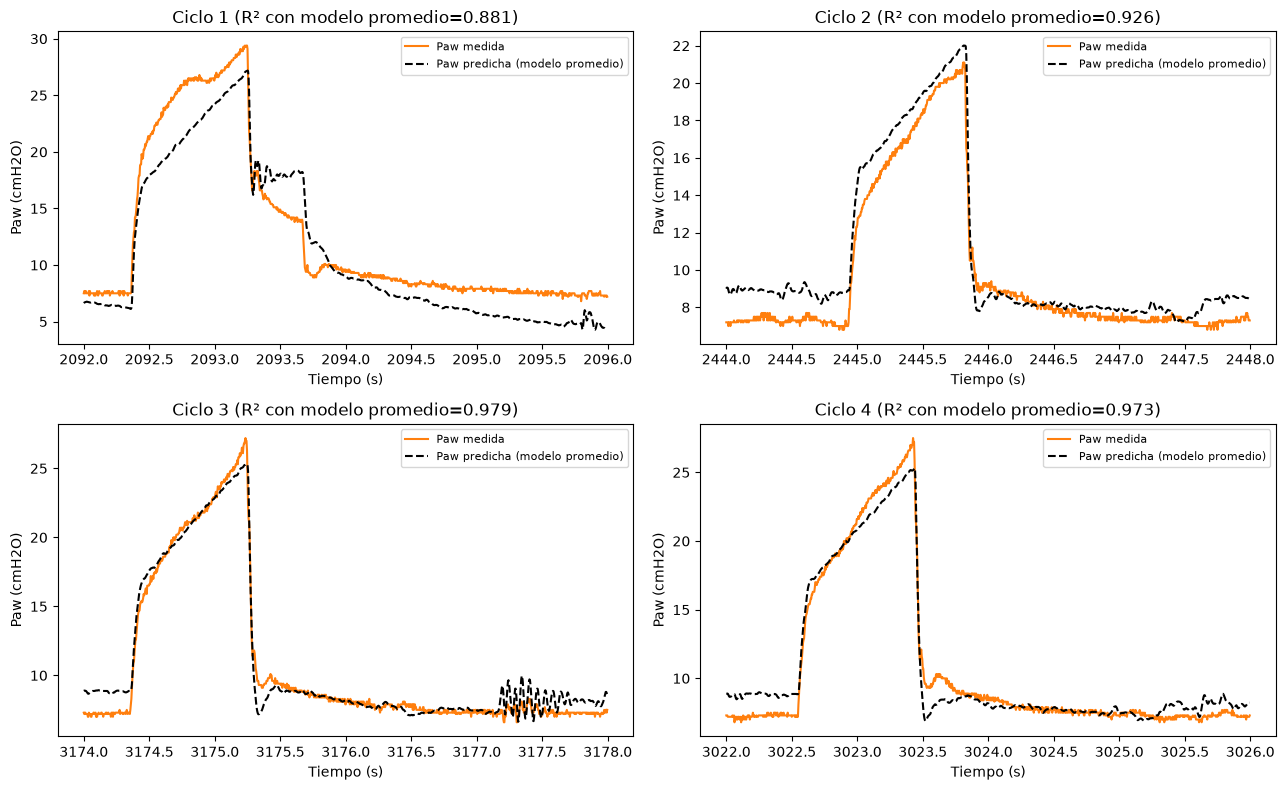

In [24]:
Rs = [r['R'] for r in resultados.values()]
Cs = [r['C']*1000 for r in resultados.values()]
PEEPs = [r['PEEP'] for r in resultados.values()]

R_prom = np.mean(Rs)
C_prom = np.mean(Cs) / 1000
E_prom = 1 / C_prom
PEEP_prom = np.mean(PEEPs)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, n in zip(axes.flat, ciclos):
    c = ciclos[n]
    F = c.Flow.values / 60.0
    V = c.Vol_L.values
    Paw = c.Paw.values

    Paw_pred_prom = R_prom * F + E_prom * V + PEEP_prom
    r2_prom = 1 - np.sum((Paw - Paw_pred_prom)**2) / np.sum((Paw - Paw.mean())**2)

    ax.plot(c.Time, Paw, label='Paw medida', color='tab:orange')
    ax.plot(c.Time, Paw_pred_prom, label='Paw predicha (modelo promedio)', color='black', linestyle='--')
    ax.set_title(f"Ciclo {n} (R² con modelo promedio={r2_prom:.3f})")
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Paw (cmH2O)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig_validacion_promedio.png', dpi=150)
plt.show()

## 7. Conclusión

A partir de la señal D (elegida entre los 4 registros disponibles por presentar la menor variabilidad de presión esofágica y la mayor cantidad de muestras), se identificaron 4 ciclos de respiración pasiva mediante un criterio cuantitativo (mínimo desvío estándar de Pes en ventanas de 4 segundos, validado visualmente), descartando en el proceso un falso positivo correspondiente a un ciclo respiratorio aislado.

Sobre cada uno de estos 4 ciclos se ajustó el modelo de 2 elementos por regresión lineal (cuadrados mínimos), obteniendo en todos los casos un alto grado de ajuste (R² entre 0.97 y 0.99). Tres de los cuatro ciclos (2, 3 y 4) arrojaron valores de Compliance y PEEP muy consistentes entre sí, mientras que el Ciclo 1 se apartó del grupo con una Compliance considerablemente mayor.

Promediando los 4 ciclos se obtuvo:
- **Resistencia (R):** ≈ 10.5 cmH2O/(L/s)
- **Compliance (C):** ≈ 67.3 mL/cmH2O
- **PEEP:** ≈ 8.9 cmH2O

Promediando únicamente los Ciclos 2, 3 y 4 (excluyendo el caso atípico) se obtiene:
- **Resistencia (R):** ≈ 9.8 cmH2O/(L/s)
- **Compliance (C):** ≈ 56.0 mL/cmH2O
- **PEEP:** ≈ 8.1 cmH2O

Ambos promedios se encuentran dentro de rangos fisiológicos normales (R: 5-15 cmH2O/(L/s); C: 50-100 mL/cmH2O), pero se observa que el Ciclo 1 desplaza notablemente la Compliance promedio hacia arriba (67.3 vs 56.0 mL/cmH2O), mientras que R y PEEP se mantienen relativamente estables en ambos casos. Esto sugiere que el resultado final es sensible a la inclusión de ciclos atípicos, reforzando la importancia de investigar la causa de esta discrepancia antes de adoptar un valor único como representativo del paciente.

La validación del modelo promediado (con los 4 ciclos) contra cada ciclo individual mostró buen ajuste en los Ciclos 2, 3 y 4 (R² entre 0.93 y 0.98), y un ajuste algo menor en el Ciclo 1 (R²=0.881), consistente con la discrepancia observada en sus parámetros individuales.

**Limitaciones y mejoras futuras:**
- La causa de la discrepancia del Ciclo 1 no fue investigada en profundidad en esta entrega; queda como punto de análisis para el cierre de la materia, evaluando si corresponde a un cambio real y puntual en la mecánica del paciente o a alguna particularidad no capturada por el criterio de selección.
- El criterio de búsqueda automática de candidatos (mínimo desvío estándar de Pes) no garantiza que la ventana elegida esté alineada con el inicio de una inspiración; en uno de los 4 ciclos esto requirió un ajuste manual del rango temporal. Un algoritmo más robusto podría alinear automáticamente cada ventana candidata con el inicio real del ciclo respiratorio, utilizando los cruces de flujo ya calculados.
- La selección de ciclos pasivos fue, en última instancia, validada de forma manual (inspección visual). Como mejora futura, se propone desarrollar un algoritmo que automatice por completo la detección de ciclos pasivos a lo largo de todo el registro, calcule la regresión sobre todos ellos y promedie los resultados sin intervención manual, permitiendo aprovechar una cantidad mucho mayor de ciclos que los 4 utilizados en esta entrega.